# M10 - Agentic Decision Support

**Goal.** Wrap the what-if simulators built in M6 to M9 as tools an LLM agent
can call, and make every number the agent cites trace back to a logged
simulation run. The output of a session is a decision memo; every cited
number carries a `[run:<run_id>]` tag pointing at the exact tool call, with
exact arguments and seed, that produced it.

**Honest scope.** This is a small-scale, single-machine implementation of the
simulation-in-the-loop pattern described in agentic-fab architectures such as
Samsung's GTC 2026 talk with NVIDIA and Synopsys (fab digital twin called by
orchestrator and specialist agents to test scenarios before acting on the
real line). It is explicitly NOT an autonomous system and does NOT use NVIDIA
tooling. On the L2 to L5 autonomy ladder Synopsys presented in the same talk,
this agent layer is task-level (L2 to L3): it runs and interprets simulations
and drafts decision memos for a human reviewer; it never acts on the real
line, and there is no real line here, only a validated synthetic simulation.

**No network calls, no API key.** Every executed cell in this notebook uses
either the deterministic Stage A replay (`src/agent/replay.py`, no LLM at
all) or the Stage B agent loop driven by `MockLLM` (`src/agent/agent_loop.py`,
a scripted stand-in for the Anthropic SDK that reads run ids and numbers out
of the tool results it is fed, never hardcoding them). The live-mode script
that calls the real Anthropic API (`scripts/run_live_agent_session.py`) is
described in Section 5 but not run here.

In [1]:
%matplotlib inline
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

NB_START = time.time()

ROOT = Path("..")
sys.path.insert(0, str(ROOT / "src" / "agent"))

from tools import ToolRegistry
from run_log import RunLogger, verify_memo_numbers
import replay
from agent_loop import (
    MOCK_QUESTION, honest_mock, fabricating_mock, run_agent_session,
)

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

print("src/agent modules imported: tools, run_log, replay, agent_loop")

src/agent modules imported: tools, run_log, replay, agent_loop


## Step 1 - The tool surface

The agent does not call the simulator directly. It calls five bounded,
logged tools registered in `src/agent/tools.py`'s `ToolRegistry`. Each tool
wraps an existing what-if engine from M6 to M9 unchanged; the registry adds
input validation, a fixed seed, and a deterministic `run_id`.

| Tool | What it answers | Bounds |
|---|---|---|
| `run_capacity_whatif` | Is an extra tool at station X worth it, CRN-paired across demand levels | station in the 7 line stations; demand_factors in [0.5, 2.0]; n_reps in [1, 30] |
| `run_demand_whatif` | What does a demand increase do to cycle time AND yield risk | demand_factor in [0.5, 2.0]; n_reps in [1, 30] |
| `run_dispatch_comparison` | Which dispatch policy wins which objective | treatments subset of {edd, critical_ratio, queue_time_aware, release_control}; n_reps in [1, 30] |
| `run_pm_timing_comparison` | When should PM be scheduled on a degrading tool | station in {LITHO, METRO}; n_reps in [1, 15] |
| `get_kpi_baseline` | Read-only current-state snapshot (throughput, cycle time, utilization) | seed locked to 42 (the documented default config seed) |

**The run_id guarantee.** `run_log.compute_run_id` hashes
`(tool_name, canonicalized_args, seed)` with SHA-256, truncated to 16 hex
characters. Canonicalization means argument order never changes the id, only
the actual values do: the same tool called with the same arguments and seed
always produces the same run_id, and changing any argument changes it. Every
call through `ToolRegistry.call(...)` is appended to a `RunLogger` before its
result is returned, so a run_id can always be looked up back to the exact
tool, arguments, seed, and result that produced it.

In [2]:
registry = ToolRegistry()
print(f"{len(registry.names())} tools registered: {registry.names()}")
print()
for schema in registry.schemas():
    print(f"- {schema['name']}")
    print(f"    {schema['description'][:110]}...")

5 tools registered: ['run_capacity_whatif', 'run_demand_whatif', 'run_dispatch_comparison', 'run_pm_timing_comparison', 'get_kpi_baseline']

- run_capacity_whatif
    Compare baseline capacity against adding one tool at a given station, CRN-paired, across demand levels. Return...
- run_demand_whatif
    Compare a demand increase (arrival-rate multiplier) against baseline, CRN-paired, reporting cycle time AND yie...
- run_dispatch_comparison
    Compare dispatching policies (edd, critical_ratio, queue_time_aware, release_control) against the FIFO baselin...
- run_pm_timing_comparison
    Compare preventive-maintenance timing alternatives (immediate/mid/late) against a no-degradation baseline for ...
- get_kpi_baseline
    Read-only baseline KPI snapshot of the locked default configuration: steady-state throughput, mean cycle time,...


In [3]:
demo_logger = RunLogger()
demo_result = registry.call(
    "get_kpi_baseline", {}, logger=demo_logger, timestamp="2026-07-07T00:00:00+00:00",
)
print("one registry.call result (get_kpi_baseline, no args):")
for k, v in demo_result.items():
    if k != "utilization":
        print(f"  {k}: {v}")
print(f"  utilization: {len(demo_result['utilization'])} station rows")
print()
print(f"run_id: {demo_result['run_id']}")
print(f"entries logged so far this session: {len(demo_logger.entries)}")

one registry.call result (get_kpi_baseline, no args):
  seed: 42
  throughput_per_hour: 0.9845679012345679
  mean_cycle_time_hours: 13.71413134939962
  run_id: 6c602a2fd7459a6c
  utilization: 7 station rows

run_id: 6c602a2fd7459a6c
entries logged so far this session: 1


## Step 2 - The traceability contract

Before any LLM enters the picture, Stage A (`src/agent/replay.py`) proves the
contract mechanically: a scripted sequence of three tool calls answers a
canned operational question, a memo is rendered
(`src/agent/memo.py::render_memo`), and every number the memo cites is
checked against the run log (`run_log.verify_memo_numbers`).

Canned question: *"Is one more litho tool worth it under 15 percent demand
growth?"*, answered by `get_kpi_baseline`, then `run_demand_whatif`, then
`run_capacity_whatif`.

In [4]:
replay_logger, replay_memo = replay.run_session()
print(f"tool calls logged: {len(replay_logger.entries)}")
print()
print(replay_memo[:900])
print("... (memo truncated for display; full memo continues with the")
print("     Assumptions/caveats and Recommendation sections)")

tool calls logged: 3

# Decision Memo

## Question

Is one more litho tool worth it under 15 percent demand growth?

## Scenarios run

- `get_kpi_baseline` (seed=42) -> run `6c602a2fd7459a6c`
- `run_demand_whatif` (demand_factor=1.15) -> run `89a105f9201ea1eb`
- `run_capacity_whatif` (station=LITHO, demand_factors=[1.0, 1.15]) -> run `774991e5e37e2fea`

## Findings

| Tool | Metric | Value | Run |
|---|---|---|---|
| get_kpi_baseline | seed | 42.00 [run:6c602a2fd7459a6c] | `6c602a2fd7459a6c` |
| get_kpi_baseline | throughput_per_hour | 0.98 [run:6c602a2fd7459a6c] | `6c602a2fd7459a6c` |
| get_kpi_baseline | mean_cycle_time_hours | 13.71 [run:6c602a2fd7459a6c] | `6c602a2fd7459a6c` |
| get_kpi_baseline | CLEAN.utilization | 0.48 [run:6c602a2fd7459a6c] | `6c602a2fd7459a6c` |
| get_kpi_baseline | FURNACE.utilization | 0.36 [run:6c602a2fd7459a6c] | `6c602a2fd7459a6c` |
| get_kpi_baseline | DEPO.utilization | 0.65 [
... (memo truncated for display; full memo continues with the
     Assumption

In [5]:
replay_report = verify_memo_numbers(replay_memo, replay_logger)
print(f"total citations found in memo : {replay_report['total_citations']}")
print(f"every citation resolves       : {replay_report['all_found']}")
print()
print("per-citation report:")
for r in replay_report["report"]:
    status = "OK" if (r["run_found"] and r["value_found"]) else "UNRESOLVED"
    print(f"  [{status:>10}] {r['citation_text']}")

total citations found in memo : 33
every citation resolves       : True

per-citation report:
  [        OK] 42.00 [run:6c602a2fd7459a6c]
  [        OK] 0.98 [run:6c602a2fd7459a6c]
  [        OK] 13.71 [run:6c602a2fd7459a6c]
  [        OK] 0.48 [run:6c602a2fd7459a6c]
  [        OK] 0.36 [run:6c602a2fd7459a6c]
  [        OK] 0.65 [run:6c602a2fd7459a6c]
  [        OK] 0.83 [run:6c602a2fd7459a6c]
  [        OK] 0.50 [run:6c602a2fd7459a6c]
  [        OK] 0.56 [run:6c602a2fd7459a6c]
  [        OK] 0.44 [run:6c602a2fd7459a6c]
  [        OK] 1.15 [run:89a105f9201ea1eb]
  [        OK] 20.00 [run:89a105f9201ea1eb]
  [        OK] 5000.00 [run:89a105f9201ea1eb]
  [        OK] 16.65 [run:89a105f9201ea1eb]
  [        OK] 0.13 [run:89a105f9201ea1eb]
  [        OK] 0.03 [run:89a105f9201ea1eb]
  [        OK] 0.00 [run:89a105f9201ea1eb]
  [        OK] -0.00 [run:89a105f9201ea1eb]
  [        OK] 67027.50 [run:89a105f9201ea1eb]
  [        OK] 20.00 [run:774991e5e37e2fea]
  [        OK] 1000.00 [run:77499

**Tamper demonstration.** If one cited number in the memo text is corrupted
(the run tag is left untouched, only the numeric value changes), verification
must flag exactly that one citation and nothing else. This is the same
tamper check `agent_check.py` GATE 3 runs as a regression gate on every
commit.

In [6]:
import re

citation_re = re.compile(r"(-?\d[\d,]*\.?\d*)(\s*[A-Za-z%$]*\s*\[run:[0-9a-fA-F]+\])")
m = citation_re.search(replay_memo)
original_number = m.group(1)
corrupted_number = "999999.999999"
tampered_memo = replay_memo[: m.start(1)] + corrupted_number + replay_memo[m.end(1) :]

print(f"corrupted citation: {original_number!r} -> {corrupted_number!r}")
print(f"(all other citations left untouched)")

tampered_report = verify_memo_numbers(tampered_memo, replay_logger)
flagged = [r for r in tampered_report["report"]
           if not (r["run_found"] and r["value_found"])]
print()
print(f"citations now flagged as unresolved: {len(flagged)}")
for r in flagged:
    print(f"  UNRESOLVED: {r['citation_text']}")
print()
n_ok = sum(1 for r in tampered_report["report"] if r["run_found"] and r["value_found"])
print(f"citations still verifying cleanly: {n_ok} of {tampered_report['total_citations']}")

corrupted citation: '42.00' -> '999999.999999'
(all other citations left untouched)

citations now flagged as unresolved: 1
  UNRESOLVED: 999999.999999 [run:6c602a2fd7459a6c]

citations still verifying cleanly: 32 of 33


## Step 3 - The agent loop with a mocked LLM

Stage B (`src/agent/agent_loop.py`) runs the same tool registry through a
manual tool-calling loop: the model (real or mocked) asks for tool calls,
the loop executes them through the logged registry, feeds results back, and
the model drafts a final answer. `MockLLM` mimics the Anthropic SDK's
response surface (`stop_reason`, `content` blocks) with a scripted sequence,
but its final answer is built by a Python function that reads run ids and
numbers out of the actual tool results passed back to it in the conversation
(`_honest_final` in `agent_loop.py`), never hardcoding them; it exercises
the exact same citation path a live model would.

Verification here is two-layered: every `[run:<id>]` citation must resolve
against the run log (as in Step 2), AND the LLM-authored final answer must
not contain an uncited substantive number (`find_uncited_numbers`: any
number with a decimal point or three-plus digits needs a `[run:<id>]` tag).

Same question as Step 2, run through the full agent loop with the honest
mock.

In [7]:
honest_session = run_agent_session(MOCK_QUESTION, honest_mock())

print(f"question: {honest_session['question']}")
print(f"model: {honest_session['model']}")
print(f"tool-call turns: {len(honest_session['turns_meta'])}")
print()
print("final answer:")
print(honest_session["final_text"])
print()
v = honest_session["verification"]
print(f"citations: {v['total_citations']}, all_found: {v['all_found']}, "
      f"uncited_numbers: {honest_session['uncited_numbers']}")
print(f"STATUS: {honest_session['status']}")

question: Is one more litho tool worth it under 15 percent demand growth?
model: MockLLM
tool-call turns: 3

final answer:
Measured effects: demand growth of 15 percent alone moves mean cycle time by 14.6176 [run:dc0da08ce32903cf] hours versus the baseline of 13.7141 [run:6c602a2fd7459a6c] hours. Adding one LITHO tool changes throughput by -0.0003 [run:58ff32ee454302b6] lots per hour at baseline demand and 0.0063 [run:58ff32ee454302b6] lots per hour under the higher demand. Recommendation: the extra LITHO tool matters more as demand grows; weigh the measured gain against tool cost before committing. This recommendation would change if the capacity delta at higher demand were measured near zero, or if the cost model ranked another station higher.

citations: 34, all_found: True, uncited_numbers: []
STATUS: VERIFIED


Now the same question, same tool calls, but the mock's final answer
appends one extra sentence with a fabricated cost figure that carries no
`[run:<id>]` tag (`fabricating_mock` in `agent_loop.py`, used only to prove
the guard works; it is never used to answer a real question in this
notebook).

In [8]:
fabricating_session = run_agent_session(MOCK_QUESTION, fabricating_mock())

print("final answer (fabricating mock):")
print(fabricating_session["final_text"])
print()
v = fabricating_session["verification"]
print(f"citations: {v['total_citations']}, all_found: {v['all_found']}, "
      f"uncited_numbers: {fabricating_session['uncited_numbers']}")
print(f"STATUS: {fabricating_session['status']}")
if fabricating_session["uncited_numbers"]:
    print()
    print(f"fabricated number named by the guard: "
          f"{fabricating_session['uncited_numbers'][0]}")

final answer (fabricating mock):
Measured effects: demand growth of 15 percent alone moves mean cycle time by 14.6176 [run:dc0da08ce32903cf] hours versus the baseline of 13.7141 [run:6c602a2fd7459a6c] hours. Adding one LITHO tool changes throughput by -0.0003 [run:58ff32ee454302b6] lots per hour at baseline demand and 0.0063 [run:58ff32ee454302b6] lots per hour under the higher demand. Recommendation: the extra LITHO tool matters more as demand grows; weigh the measured gain against tool cost before committing. This recommendation would change if the capacity delta at higher demand were measured near zero, or if the cost model ranked another station higher. Additionally this change saves 123456.78 dollars per quarter in congestion cost.

citations: 34, all_found: True, uncited_numbers: ['123456.78']
STATUS: FAILED VERIFICATION

fabricated number named by the guard: 123456.78


**Why this matters.** The fabricated figure (123456.78) is not a subtle
error; it is a clean-looking, plausible-sounding dollar amount an LLM could
easily produce as confident-sounding narrative. The loop does not rely on the
model policing itself, and it does not rely on a human reviewer happening to
notice. `find_uncited_numbers` scans the final answer text mechanically for
any substantive number lacking a `[run:<id>]` tag, and `verify_memo_numbers`
independently checks every tag that IS present against the run log. Both
checks are structural, not semantic; the loop cannot silently accept an
invented number, honest mock or not, mocked LLM or live one, because the same
two checks run on both.

**Figure.** Citations found vs. not-found across the three verification
cases run above: the clean replay memo (Step 2), the tampered replay memo
(Step 2), and the honest vs. fabricating mocked-LLM sessions (Step 3).

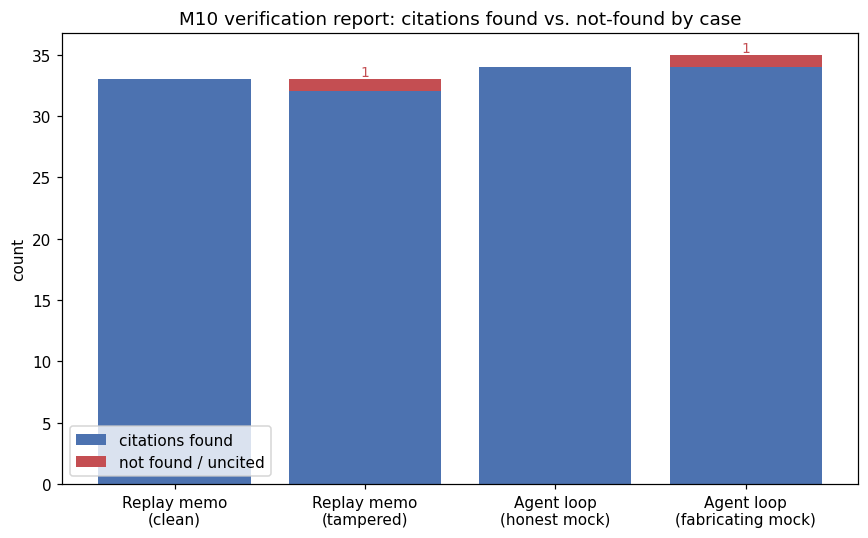

saved reports/figures/m10_verification_report.png


In [9]:
cases = []

n_found = sum(1 for r in replay_report["report"] if r["run_found"] and r["value_found"])
n_total = replay_report["total_citations"]
cases.append(("Replay memo\n(clean)", n_found, n_total - n_found))

n_found_t = sum(1 for r in tampered_report["report"] if r["run_found"] and r["value_found"])
n_total_t = tampered_report["total_citations"]
cases.append(("Replay memo\n(tampered)", n_found_t, n_total_t - n_found_t))

hv = honest_session["verification"]
n_found_h = sum(1 for r in hv["report"] if r["run_found"] and r["value_found"])
cases.append(("Agent loop\n(honest mock)", n_found_h, hv["total_citations"] - n_found_h))

fv = fabricating_session["verification"]
n_found_f = sum(1 for r in fv["report"] if r["run_found"] and r["value_found"])
# the fabricated number is uncited (never a citation at all), so it is
# tracked separately from the citation-report found/not-found split
n_uncited_f = len(fabricating_session["uncited_numbers"])
cases.append(("Agent loop\n(fabricating mock)", n_found_f, n_uncited_f))

labels = [c[0] for c in cases]
found_vals = [c[1] for c in cases]
notfound_vals = [c[2] for c in cases]

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(labels))
ax.bar(x, found_vals, label="citations found", color="#4C72B0")
ax.bar(x, notfound_vals, bottom=found_vals, label="not found / uncited", color="#C44E52")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("count")
ax.set_title("M10 verification report: citations found vs. not-found by case")
ax.legend()
for i, (f, nf) in enumerate(zip(found_vals, notfound_vals)):
    if nf > 0:
        ax.annotate(str(nf), (i, f + nf), ha="center", va="bottom", color="#C44E52", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "m10_verification_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved reports/figures/m10_verification_report.png")

## Step 4 - Live mode (described, not run)

`scripts/run_live_agent_session.py` runs one live session against the real
Anthropic API (model `claude-opus-4-8`, via `AnthropicLLM` in
`agent_loop.py`) through the exact same `run_agent_session` loop exercised
above with `MockLLM`. It is gated on credentials and is not run by this
notebook.

- **Credential guard.** `AnthropicLLM.check_credentials` checks for
  `ANTHROPIC_API_KEY` or `ANTHROPIC_AUTH_TOKEN` in the environment before any
  network call is attempted; missing credentials raise
  `AgentCredentialError` with a one-line message naming the required
  variable, never a raw SDK stack trace. `loop_check.py` GATE 5 verifies this
  guard with a scrubbed environment, offline.
- **What it saves.** Each invocation creates
  `reports/agent_sessions/session_<UTC timestamp>/`, containing
  `transcript.json` (question, model, per-turn tool-call accounting, final
  answer, citation verification report, uncited-number check, status, and the
  full run log) and `memo.md` (the rendered decision memo). Exactly one
  session is saved per invocation.
- **Exit codes** make the verification outcome visible to the shell:
  0 = session VERIFIED, 1 = missing credentials, 2 = the session ran but
  FAILED VERIFICATION (still saved, flagged, for inspection, never silently
  discarded).
- **Public evidence.** Once run with the project owner's credentials, live
  session transcripts are committed to the repository under
  `reports/agent_sessions/` as public evidence of the mechanism working
  end to end against a real model, the same traceability contract
  demonstrated with `MockLLM` above, just with a live model drafting the
  final answer instead of a scripted stand-in.

## Step 5 - Closing

**What M10 adds.** Every number that appears in an agent-drafted decision
memo now traces to a logged simulation run: tool, arguments, seed, and
result. The chain runs from `ToolRegistry.call` (bounded inputs, deterministic
run_id, mandatory log entry) through `render_memo` (every number written as
`<value> [run:<id>]`) to `verify_memo_numbers` (every citation checked
against the log) and `find_uncited_numbers` (nothing substantive escapes
uncited). This is demonstrated twice: mechanically with no LLM at all
(Step 2, the Stage A replay) and with a mocked LLM driving the full
tool-calling loop (Step 3, Stage B), including a deliberate fabrication case
proving the guard actually catches an invented number rather than trusting
the model's honesty.

**Limits.** The mocked LLM demonstrates the traceability mechanism, not
answer quality; `MockLLM`'s final-answer text is a scripted Python function
reading real tool results, not a model reasoning about the question. Live
sessions against the real Anthropic API are pending the project owner's
credentials (Step 4); when run, they exercise the identical verification
path, so the mechanism proven here transfers directly. The tool surface
itself is bounded to the five registered tools; the agent cannot call
anything else, run unbounded replications, or bypass the run log.

**Verification.** `src/agent/agent_check.py` (5 gates: reproducibility,
traceability, tamper detection, schema validity and bounds rejection, run_id
integrity) and `src/agent/loop_check.py` (5 gates: loop mechanics,
traceability, fabrication catch, reproducibility, credential guard) both
exit 0 and are re-run alongside every other check script in this project
before this notebook's numbers are trusted.

In [10]:
print(f"notebook wall time: {time.time() - NB_START:.1f} s")

notebook wall time: 16.5 s
